In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from lightning.pytorch import seed_everything
import random

from solo.data.classification_dataloader import prepare_data

from train_decoding import CifarDecoder, get_training_data


In [ ]:
dataset = "cifar10"
val_data_path = "../datasets/"
train_data_path = "../datasets/"
data_format = "image_folder"
batch_size = 256
num_workers = 4

In [3]:
# model names
model_name = "featureprob"
run_name = "featureprob-cifar10"

# get training data
seed_everything(0, workers=True)
seed_value=0
np.random.seed(seed_value) # cpu vars
torch.manual_seed(seed_value) # cpu  vars
random.seed(seed_value) # Python
torch.cuda.manual_seed(seed_value)
torch.cuda.manual_seed_all(seed_value)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
model, train_data, train_z, val_data, val_z = get_training_data(
    model_name=model_name,
    run_name=run_name,
    dataset=dataset,
    train_data_path=train_data_path,
    val_data_path=val_data_path,
    data_format=data_format,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False
)


Seed set to 0


In [4]:
model_name2 = "vicreg"
run_name2 = "vicreg-cifar10"

# get training data
seed_everything(0, workers=True)
seed_value=0
np.random.seed(seed_value) # cpu vars
torch.manual_seed(seed_value) # cpu  vars
random.seed(seed_value) # Python
torch.cuda.manual_seed(seed_value)
torch.cuda.manual_seed_all(seed_value)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
model2, train_data2, train_z2, val_data2, val_z2 = get_training_data(
    model_name=model_name2,
    run_name=run_name2,
    dataset=dataset,
    train_data_path=train_data_path,
    val_data_path=val_data_path,
    data_format=data_format,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False,
)

Seed set to 0


In [5]:
latent_dim = train_z.shape[1]
decoder = CifarDecoder(latent_dim=latent_dim).to("cuda:0")

decoder_name = f"./decoders/{model_name}_{run_name}_decoder.pth"
decoder.load_state_dict(torch.load(decoder_name))
decoder.eval()
decoder.cuda()

latent_dim2 = train_z2.shape[1]
decoder2 = CifarDecoder(latent_dim=latent_dim2).to("cuda:0")
decoder_name2 = f"./decoders/{model_name2}_{run_name2}_decoder.pth"
decoder2.load_state_dict(torch.load(decoder_name2))
decoder2.eval()
decoder2.cuda()

CifarDecoder(
  (fc): Sequential(
    (0): Linear(in_features=2048, out_features=2048, bias=True)
  )
  (conv_layers): Sequential(
    (0): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): ReLU()
    (2): ConvTranspose2d(128, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ReLU()
    (5): ConvTranspose2d(32, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): ConvTranspose2d(16, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (9): Sigmoid()
  )
)

In [6]:
# decode some images
val_z = torch.tensor(val_z).to("cuda:0")
with torch.no_grad():
    decoded_imgs = decoder(val_z).cpu().numpy()

val_z2 = torch.tensor(val_z2).to("cuda:0")
with torch.no_grad():
    decoded_imgs2 = decoder2(val_z2).cpu().numpy()

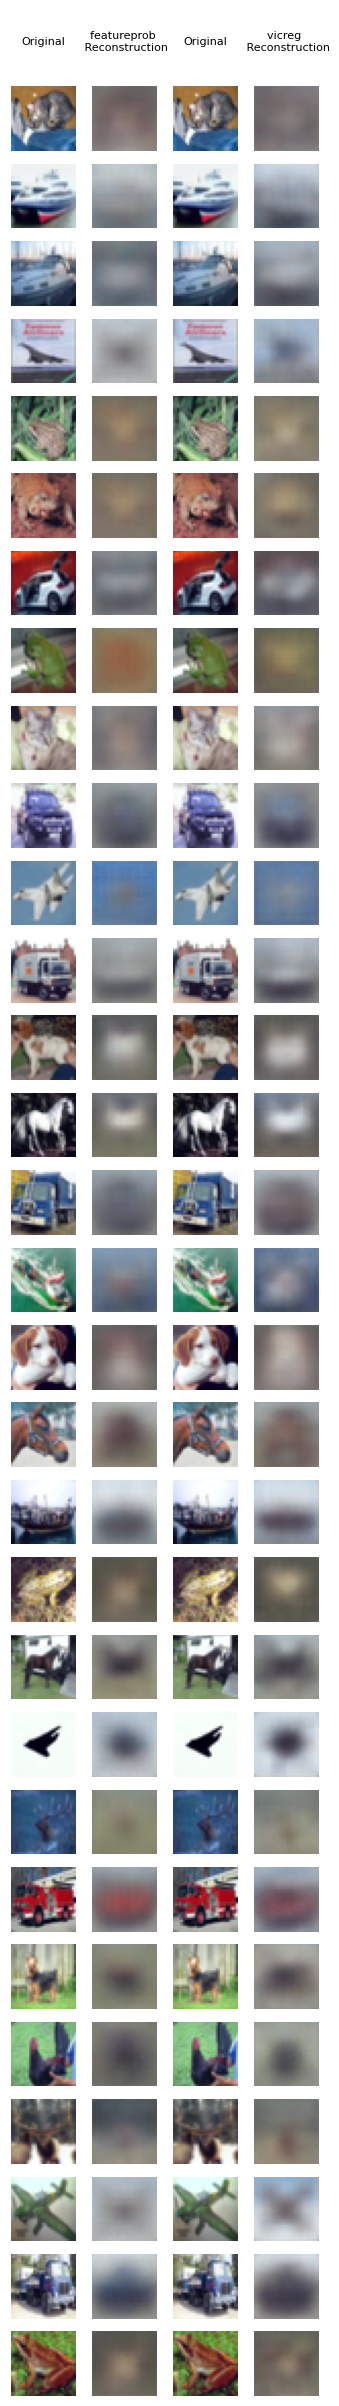

In [7]:
n = 30
fig, axs = plt.subplots(n+1, 4, figsize=(4, n+1))
# set titles
axs[0, 0].text(0.5, 0.5, "Original", fontsize=8, ha='center', va='center')
axs[0, 1].text(0.5, 0.5, f"{model_name} \n Reconstruction", fontsize=8, ha='center', va='center')
axs[0, 2].text(0.5, 0.5, "Original", fontsize=8, ha='center', va='center')
axs[0, 3].text(0.5, 0.5, f"{model_name2} \n Reconstruction", fontsize=8, ha='center', va='center')
axs[0, 0].axis("off")
axs[0, 1].axis("off")
axs[0, 2].axis("off")
axs[0, 3].axis("off")
for i in range(n):
    # display original
    axs[i+1, 0].imshow(val_data[i].transpose(1, 2, 0))
    axs[i+1, 0].axis("off")
    # display reconstruction
    axs[i+1, 1].imshow(decoded_imgs[i].transpose(1, 2, 0))
    axs[i+1, 1].axis("off")
    axs[i+1, 2].imshow(val_data2[i].transpose(1, 2, 0))
    axs[i+1, 2].axis("off")
    axs[i+1, 3].imshow(decoded_imgs2[i].transpose(1, 2, 0))
    axs[i+1, 3].axis("off")
plt.show()